# DAgger — Dataset Aggregation for Behavior Cloning
**REF:** Ross et al. (2011) "A Reduction of Imitation Learning and Structured Prediction to No-Regret Online Learning." AISTATS 2011.

## Why DAgger
Open-loop BC achieves 0.058m ADE but 49.4m closed-loop L2 — an 850x gap caused by covariate shift.
BC is trained on expert states only. In closed-loop, the ego drifts off the expert trajectory at step 1
and visits states the policy was never trained on. Error compounds.

DAgger fix:
1. Run policy closed-loop
2. At each visited state, record what the **expert** would have done (label correction)
3. Aggregate: D_new = D_orig + D_on_policy
4. Retrain on D_new
5. Repeat — each iteration the policy sees more of its own failure modes

## This notebook
- Iter 0: baseline BC (already done in bc_pipeline.ipynb)
- Iter 1: run BCPlanner closed-loop, collect on-policy data, retrain -> BC_v1
- Eval: compare closed-loop L2 of BC_v0 vs BC_v1


In [1]:
# Cell 1 — Imports and config
# WHY nest_asyncio: nuPlan's run_simulation calls asyncio.run() internally.
# Jupyter kernels already run an event loop (IPykernel). asyncio.run() raises
# RuntimeError when called from inside a running loop. nest_asyncio patches
# the running loop to allow nested asyncio.run() calls — standard fix for
# nuPlan-in-Jupyter workflows.
import nest_asyncio
nest_asyncio.apply()

import os, sys, sqlite3, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

sys.path.insert(0, '/Users/parvpatodia/nuplan-devkit')
sys.path.insert(0, '/Users/parvpatodia/Desktop/diffusion-policy-zoo/nuplan')

os.environ.setdefault('NUPLAN_DATA_ROOT', '/Users/parvpatodia/nuplan-devkit/data/cache')
os.environ.setdefault('NUPLAN_MAPS_ROOT', '/Users/parvpatodia/nuplan-devkit/maps')
os.environ.setdefault('NUPLAN_EXP_ROOT',  '/Users/parvpatodia/nuplan-devkit/exp')
os.environ.setdefault('NUPLAN_TUTORIAL_PATH', '/Users/parvpatodia/nuplan-devkit/tutorials')

from planners import BCPolicy, BCPlanner, DAggerPlanner

CKPT_V0   = Path('checkpoints/bc_best.pt')          # pure BC (from bc_pipeline.ipynb)
CKPT_V1   = Path('checkpoints/bc_dagger_v1.pt')     # DAgger iter 1 (no improvement — 0.3% on-policy)
CKPT_V2   = Path('checkpoints/bc_dagger_v2.pt')     # DAgger iter 2 — this notebook produces this
DB_DIR    = Path('/Users/parvpatodia/nuplan-devkit/data/cache/mini')
SIM_DIR   = Path('sim_results')
DEVICE    = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
FUTURE_STEPS = 16

print(f'Device: {DEVICE}')
print(f'BC_v0 checkpoint: {CKPT_V0.exists()}')
print(f'BC_v1 checkpoint: {CKPT_V1.exists()} (iter 1 — 745 samples, no improvement)')
print(f'DB files: {len(list(DB_DIR.glob("*.db")))}')


Device: mps
BC_v0 checkpoint: True
BC_v1 checkpoint: True (iter 1 — 745 samples, no improvement)
DB files: 64


In [2]:
# Cell 2 — Load original BC training data (iter 0 dataset)
# WHY: DAgger aggregates on top of the original expert data.
#      We need the original X, Y arrays to merge with on-policy data later.

def quat_to_yaw(qw, qx, qy, qz):
    return np.arctan2(2.0*(qw*qz + qx*qy), 1.0 - 2.0*(qy**2 + qz**2))

def extract_from_db(db_path, stride=10):
    conn = sqlite3.connect(str(db_path))
    rows = conn.execute(
        'SELECT x, y, qw, qx, qy, qz, vx, vy, acceleration_x, acceleration_y '
        'FROM ego_pose ORDER BY timestamp'
    ).fetchall()
    conn.close()
    if len(rows) < FUTURE_STEPS + 1:
        return None, None
    arr = np.array(rows, dtype=np.float64)
    yaw = quat_to_yaw(arr[:,2], arr[:,3], arr[:,4], arr[:,5])
    vx, vy, ax, ay = arr[:,6], arr[:,7], arr[:,8], arr[:,9]
    x_g, y_g = arr[:,0], arr[:,1]
    N = len(arr)
    inputs, targets = [], []
    for i in range(0, N - FUTURE_STEPS, stride):
        feat = np.array([np.sin(yaw[i]), np.cos(yaw[i]), vx[i], vy[i], ax[i], ay[i]], dtype=np.float32)
        cx, cy, cyaw = x_g[i], y_g[i], yaw[i]
        cos_h, sin_h = np.cos(-cyaw), np.sin(-cyaw)
        tgt = np.zeros(FUTURE_STEPS * 3, dtype=np.float32)
        for j in range(FUTURE_STEPS):
            fi = i + j + 1
            dx_w, dy_w = x_g[fi] - cx, y_g[fi] - cy
            dx_e = cos_h * dx_w - sin_h * dy_w
            dy_e = sin_h * dx_w + cos_h * dy_w
            dyaw = yaw[fi] - cyaw
            dyaw = (dyaw + np.pi) % (2*np.pi) - np.pi
            tgt[j*3], tgt[j*3+1], tgt[j*3+2] = dx_e, dy_e, dyaw
        inputs.append(feat)
        targets.append(tgt)
    return np.array(inputs, dtype=np.float32), np.array(targets, dtype=np.float32)

all_X, all_Y = [], []
for db in sorted(DB_DIR.glob('*.db'))[:64]:
    Xi, Yi = extract_from_db(db)
    if Xi is not None:
        all_X.append(Xi); all_Y.append(Yi)

X_orig = np.concatenate(all_X, axis=0)
Y_orig = np.concatenate(all_Y, axis=0)
print(f'Original dataset: {X_orig.shape[0]:,} windows')


Original dataset: 260,636 windows


Collection policy: bc_dagger_v1.pt
Target: 20 logs × 5 scenarios ≈ 15,000 samples
[ 1/20] 2021.05.12.22.00.38_veh-35_01008_01518 ...  

/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/run_simulation.py:99: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path=CONFIG_PATH, config_name=CONFIG_NAME)
/opt/anaconda3/envs/nuplan/lib/python3.9/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'default_simulation': Defaults list is missing `_self_`. See https://hydra.cc/docs/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


Seed set to 0


INFO:nuplan.planning.script.builders.main_callback_builder:Building MultiMainCallback...


INFO:nuplan.planning.script.builders.main_callback_builder:Building MultiMainCallback: 4...DONE!


...

Rendering histograms: 100%|██████████| 4/4 [00:00<00:00, 23.26it/s]

2026-05-24 16:42:46,210 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/main_callback/metric_summary_callback.py:344}  Metric summary: 00:00:00 [HH:MM:SS]
2026-05-24 16:42:46,210 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/main_callback/metric_summary_callback.py:344}  Metric summary: 00:00:00 [HH:MM:SS]
2026-05-24 16:42:46,210 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/run_simulation.py:80}  Finished running simulation!
2026-05-24 16:42:46,210 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/run_simulation.py:80}  Finished running simulation!
 747 samples
[20/20] 2021.06.09.17.23.18_veh-38_00773_01140 ...  

/opt/anaconda3/envs/nuplan/lib/python3.9/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'default_simulation': Defaults list is missing `_self_`. See https://hydra.cc/docs/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


Seed set to 0


2026-05-24 16:42:47,316 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/main_callback_builder.py:20}  Building MultiMainCallback...
2026-05-24 16:42:47,316 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/main_callback_builder.py:20}  Building MultiMainCallback...
2026-05-24 16:42:47,321 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/main_callback_builder.py:35}  Building MultiMainCallback: 4...DONE!
2026-05-24 16:42:47,321 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/main_callback_builder.py:35}  Building MultiMainCallback: 4...DONE!
2026-05-24 16:42:47,355 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/worker_pool_builder.py:19}  Building WorkerPool...
2026-05-24 16:42:47,355 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/worker_pool_builder.py:19}  Building WorkerPool...
2026-05-24 16:42:47,357 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/pl

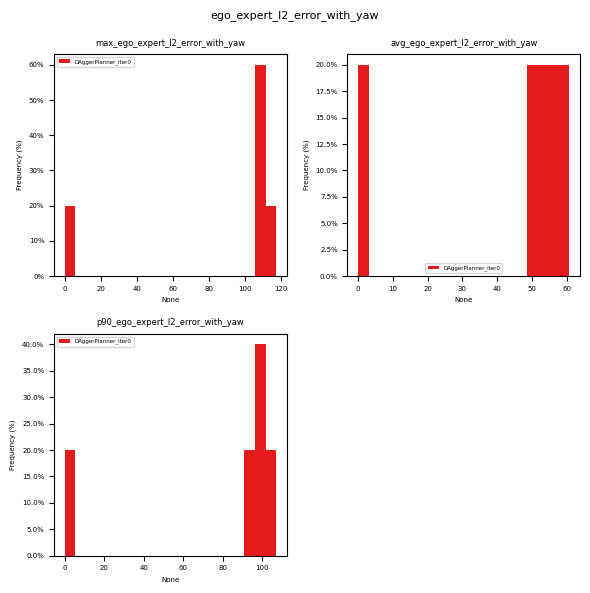

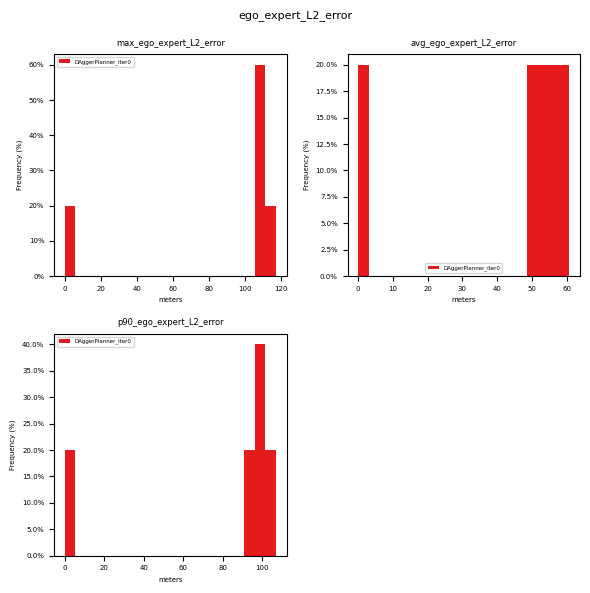

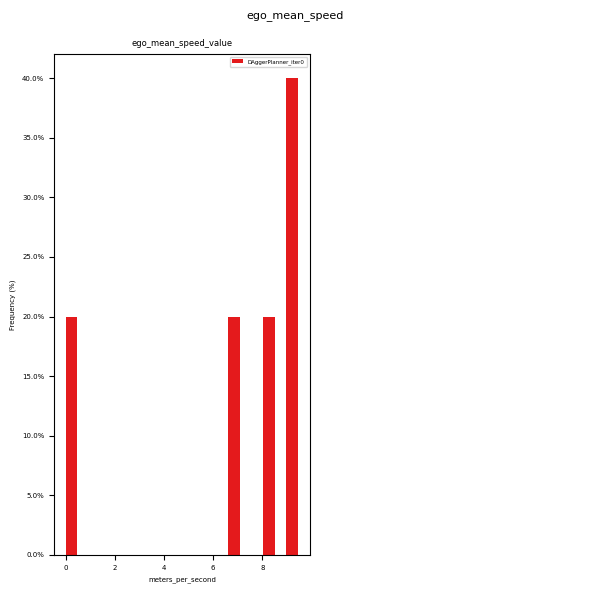

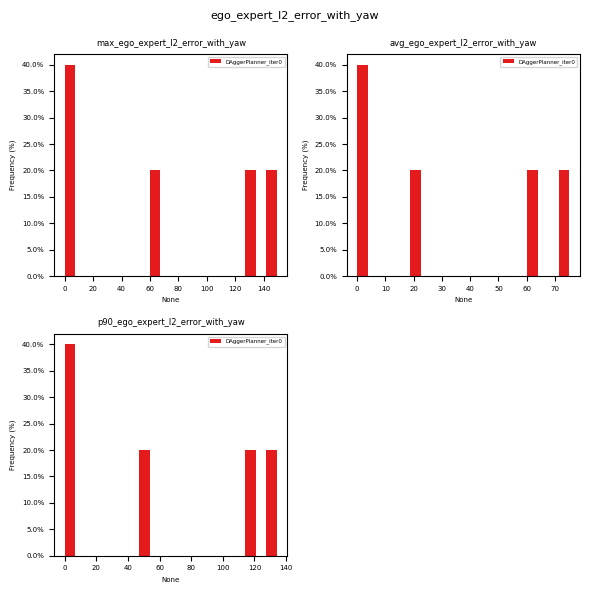

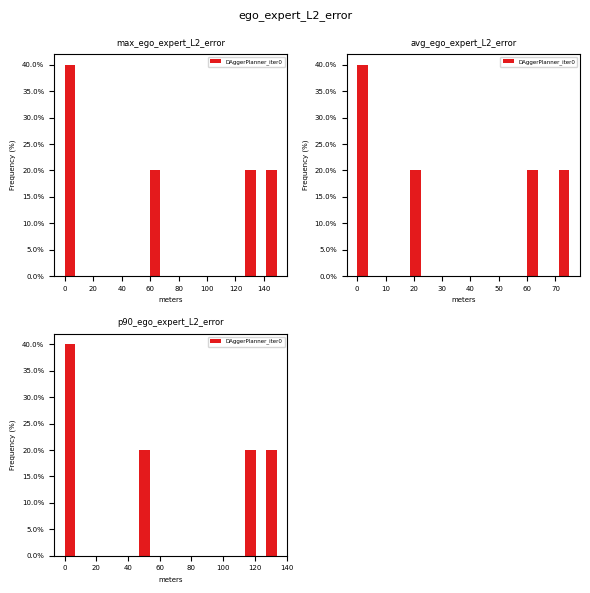

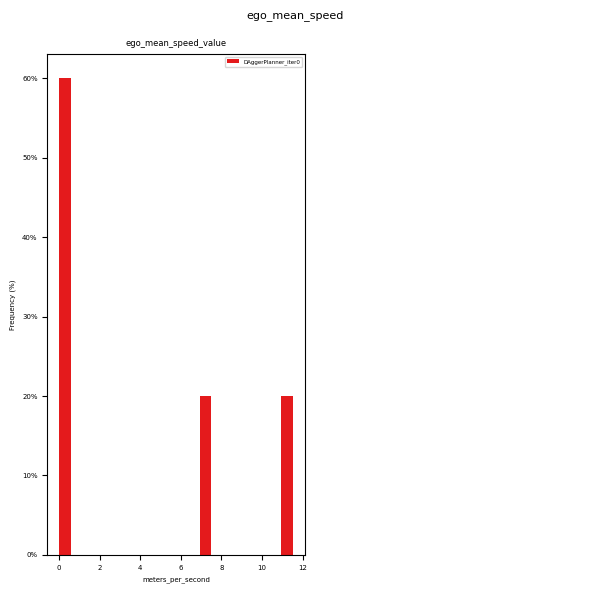

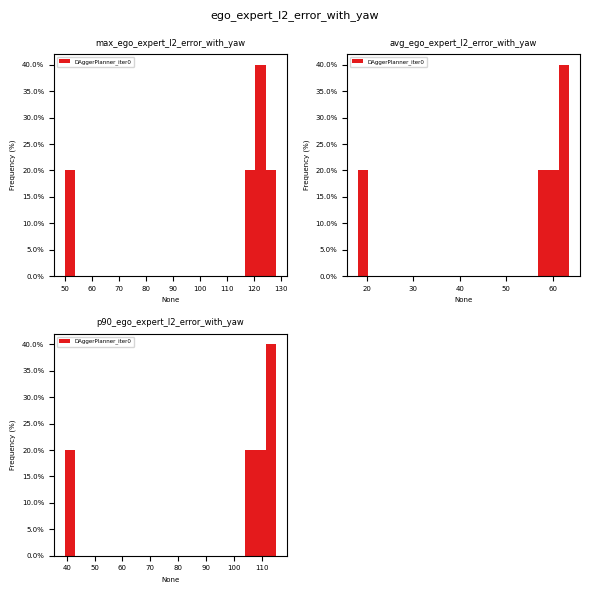

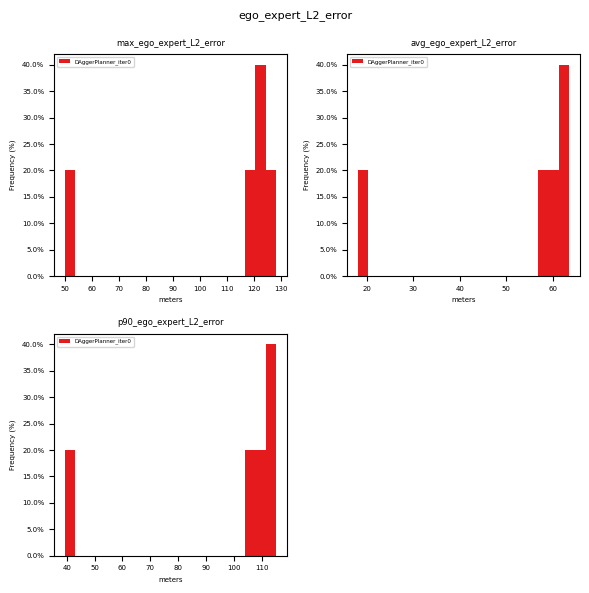

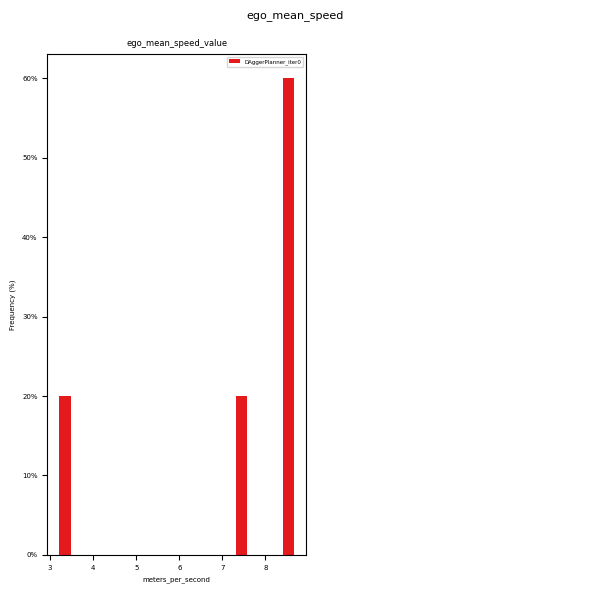

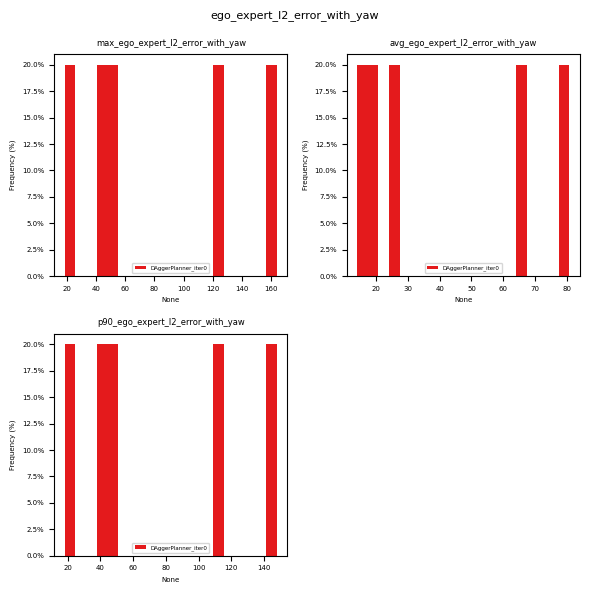

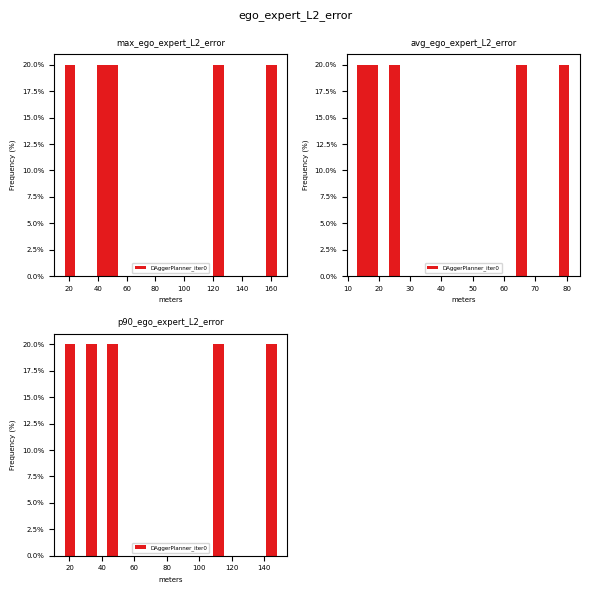

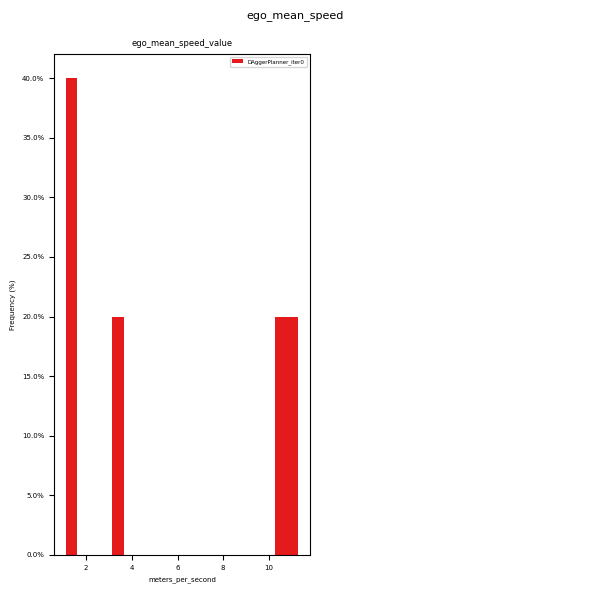

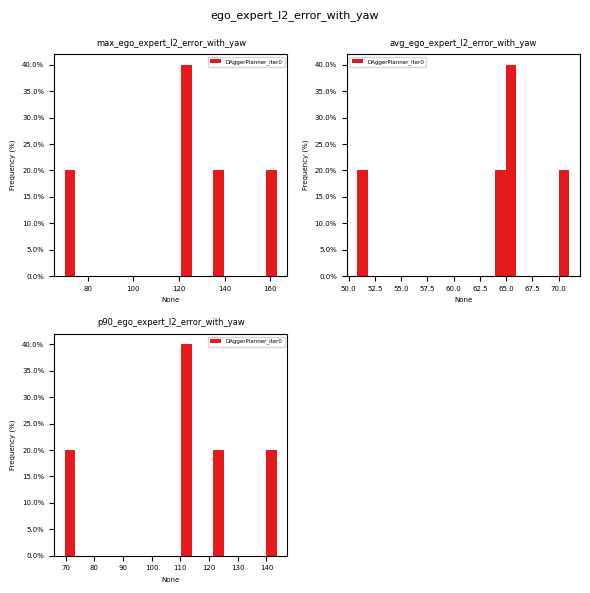

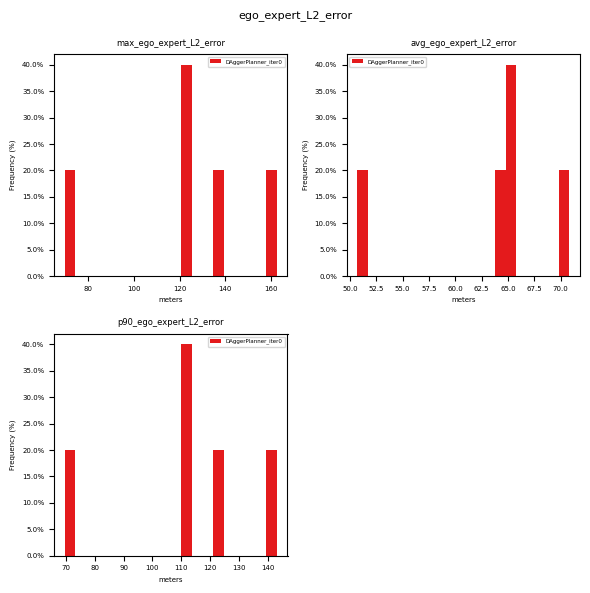

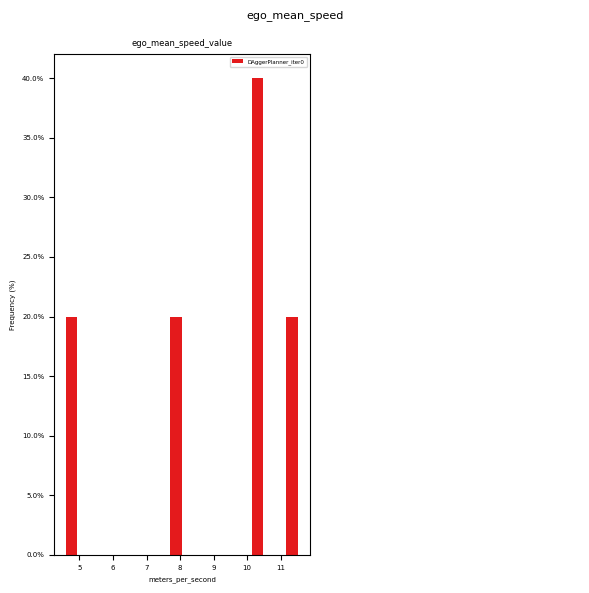

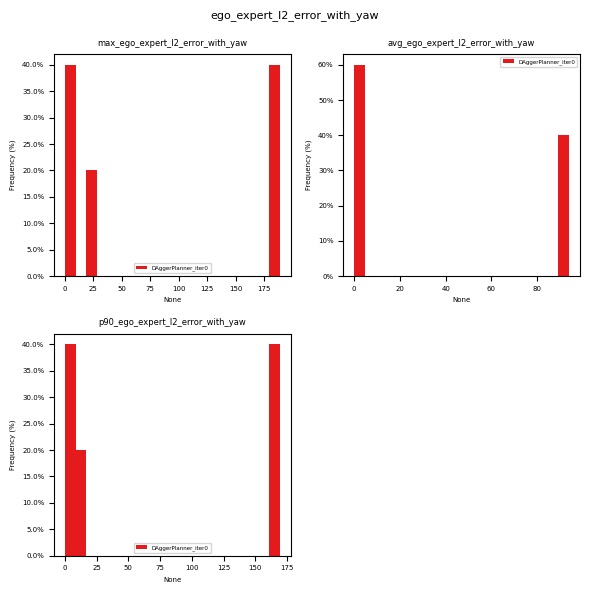

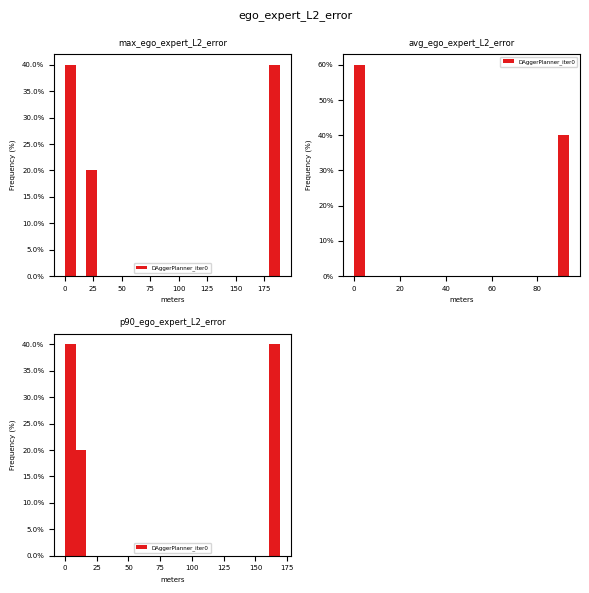

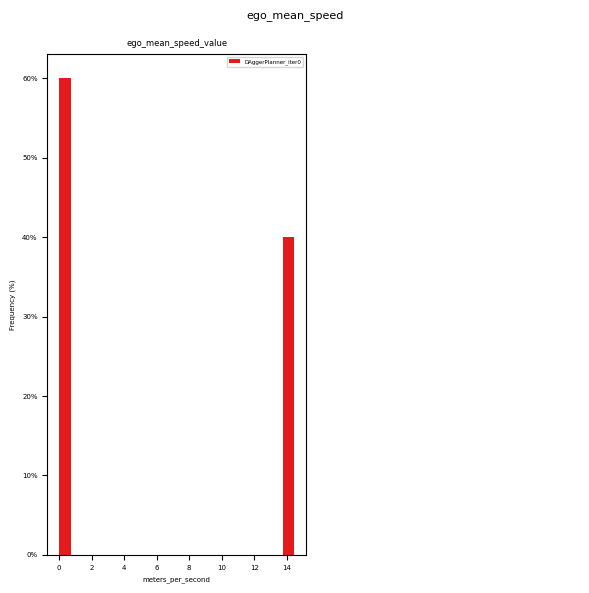

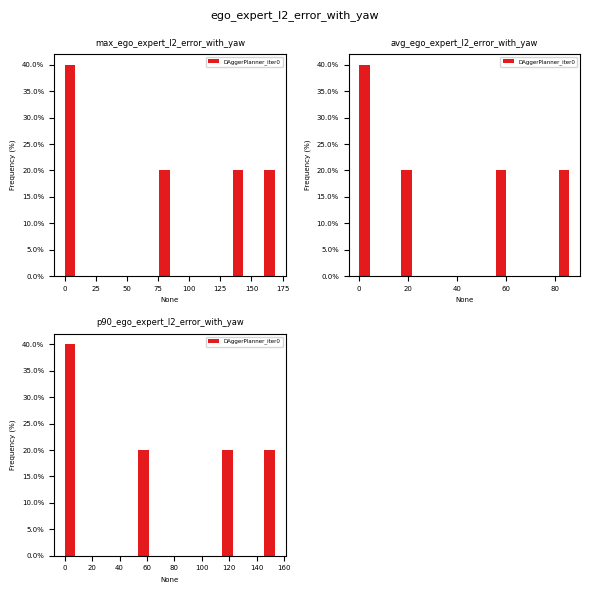

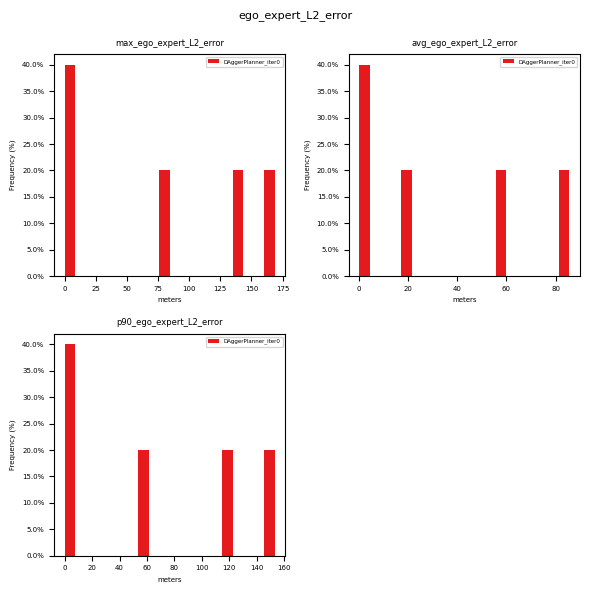

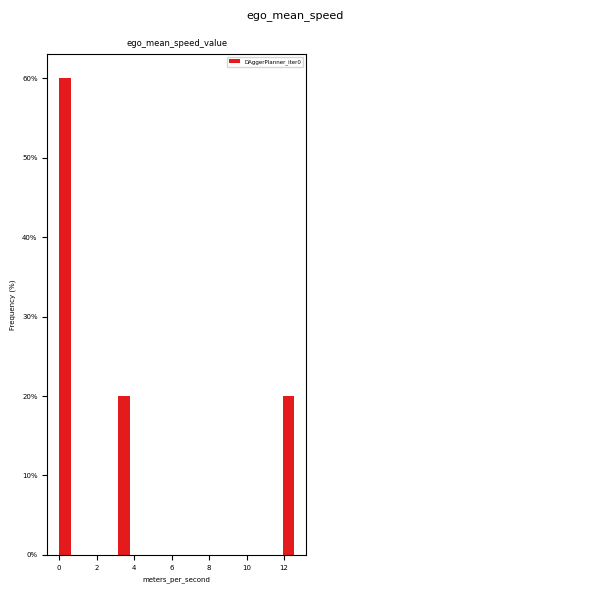

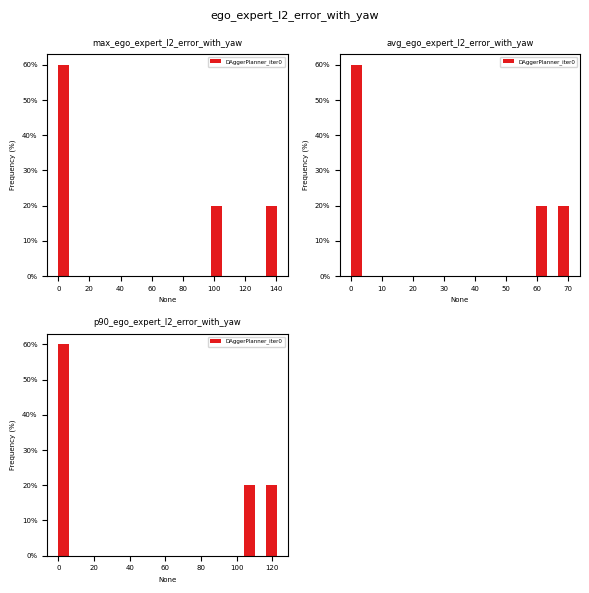

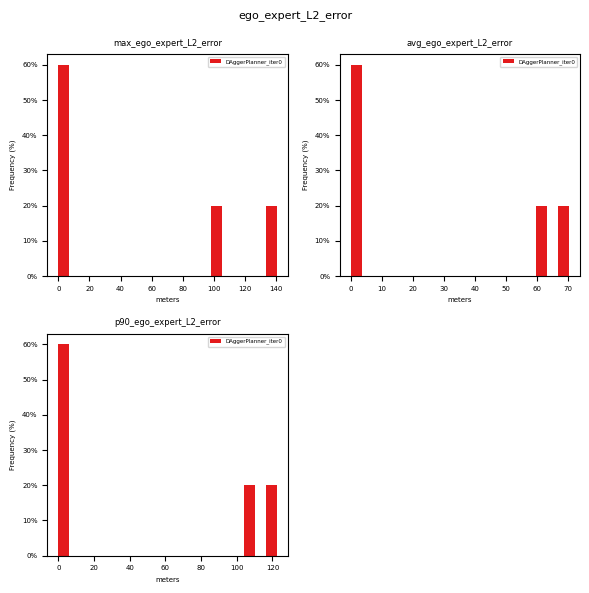

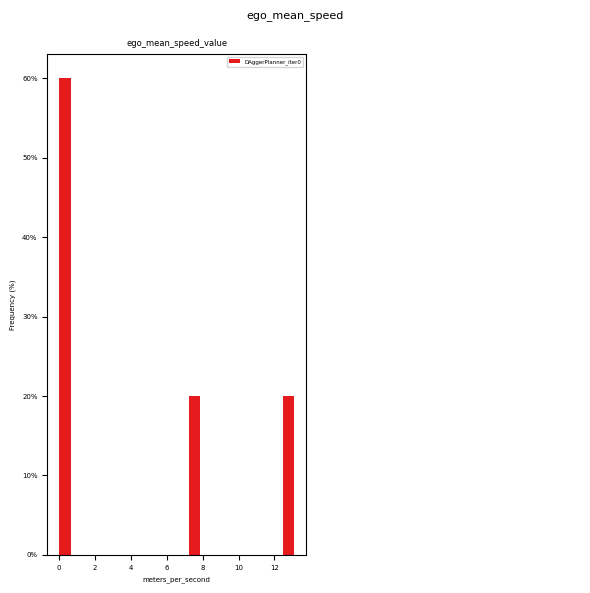

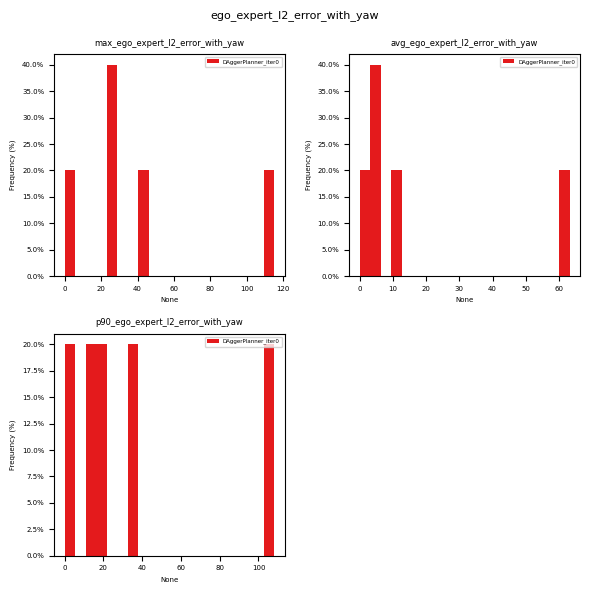

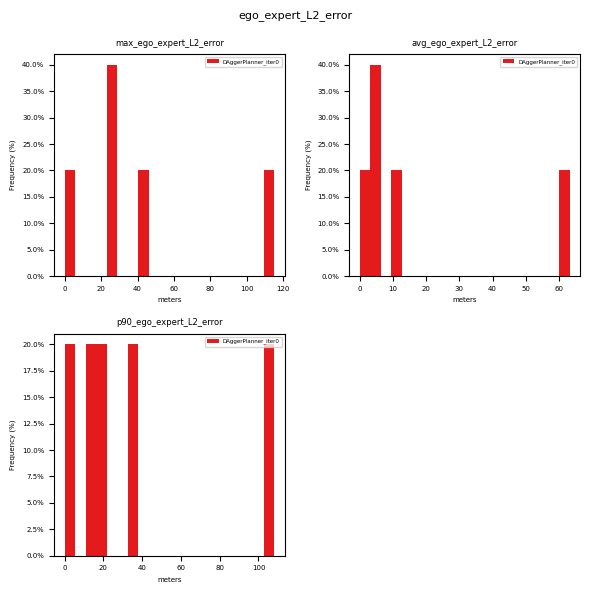

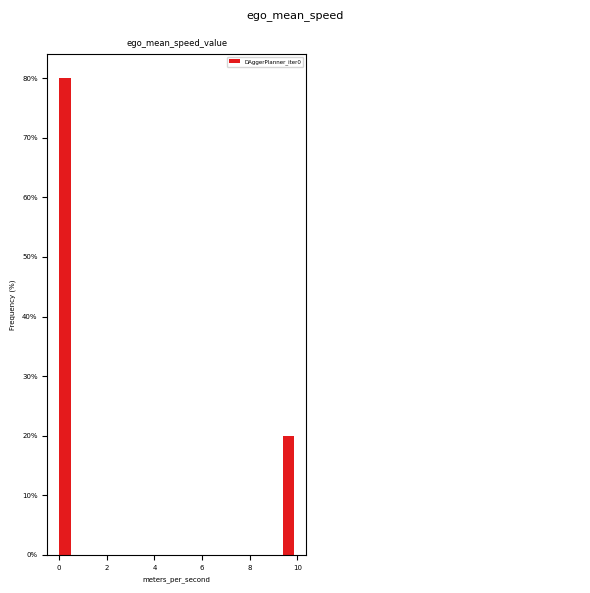

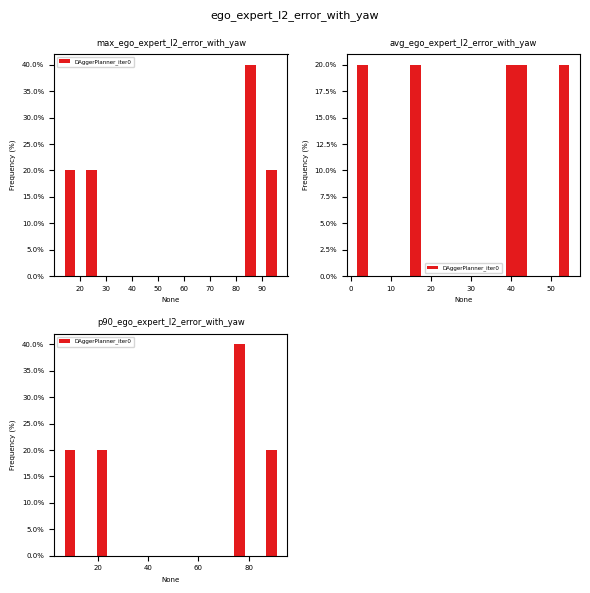

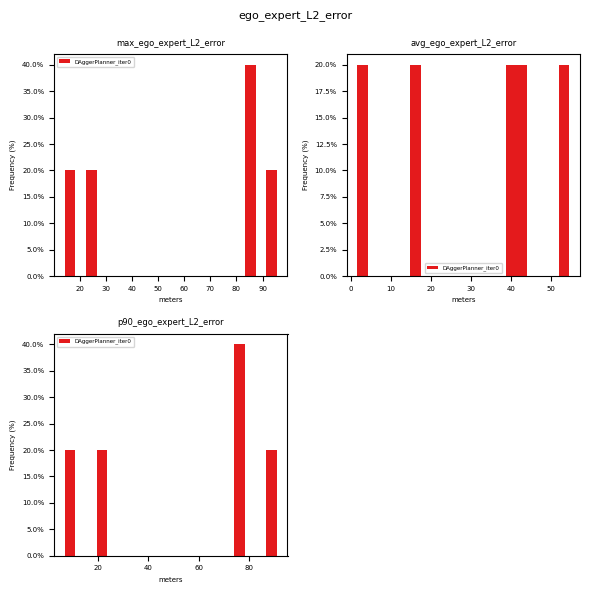

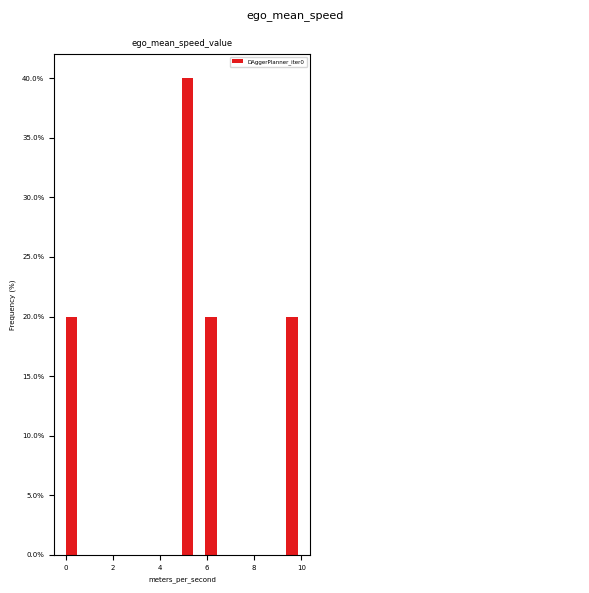

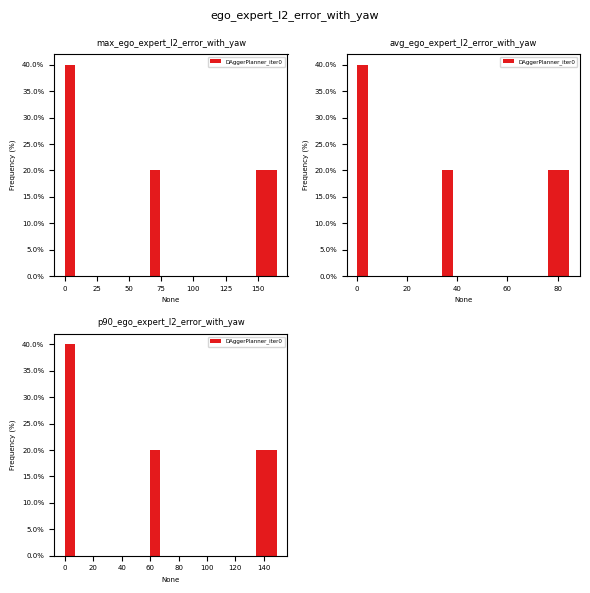

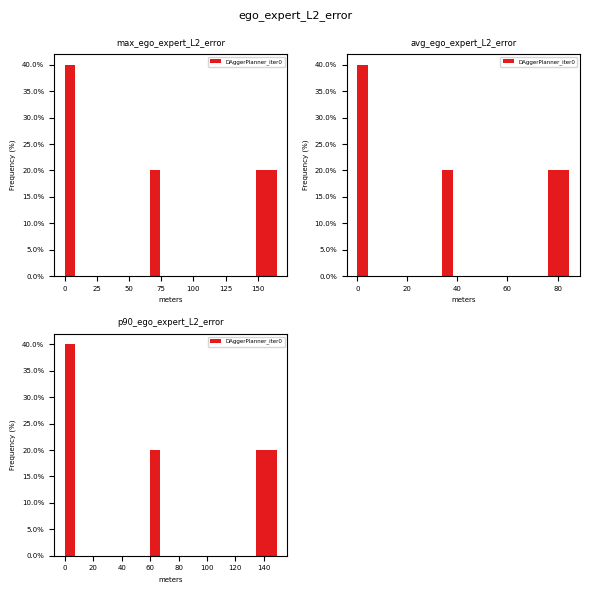

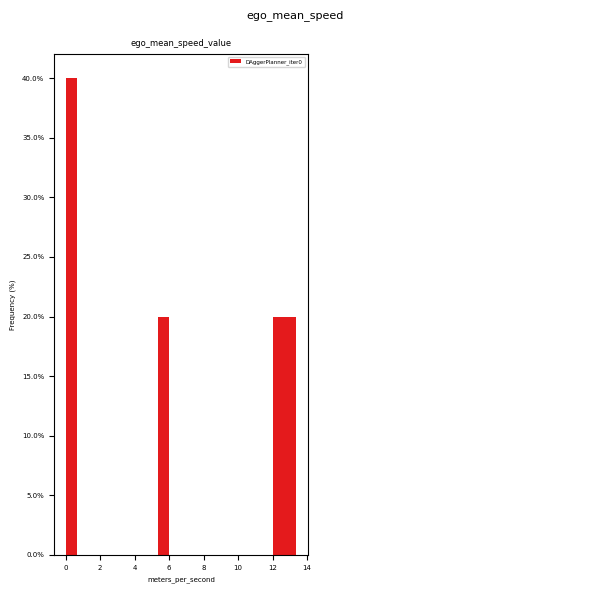

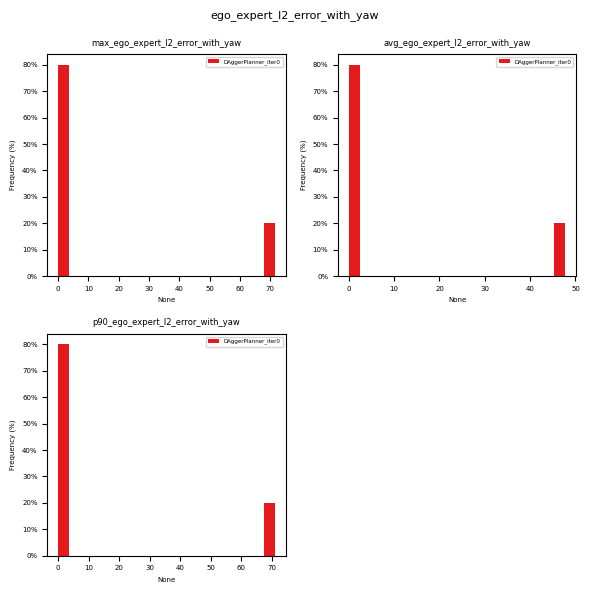

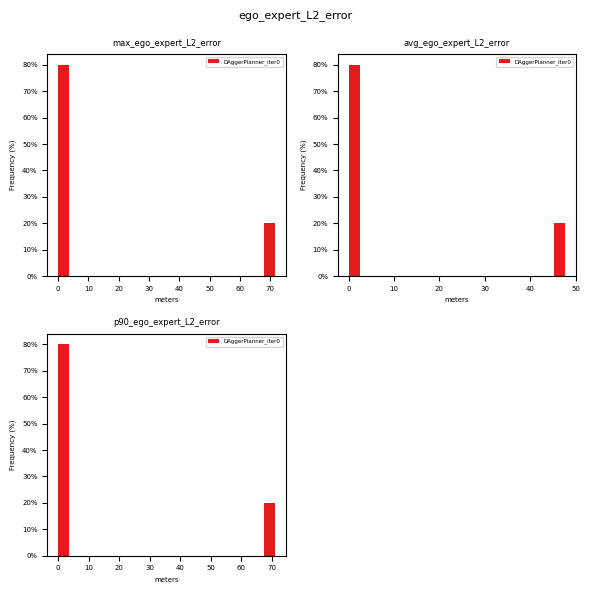

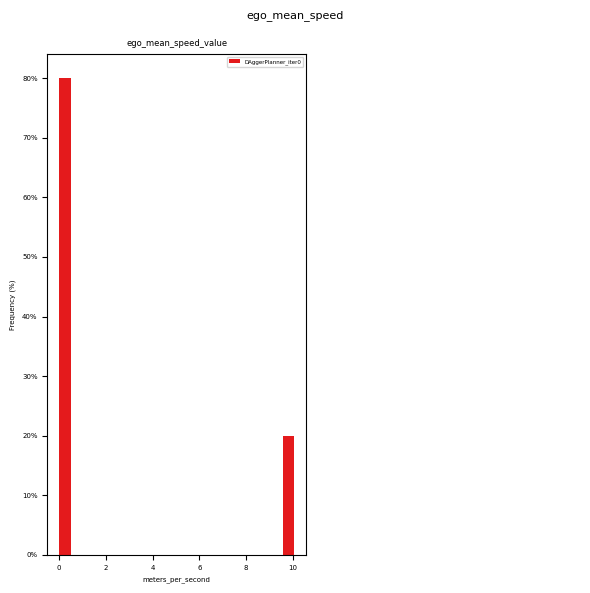

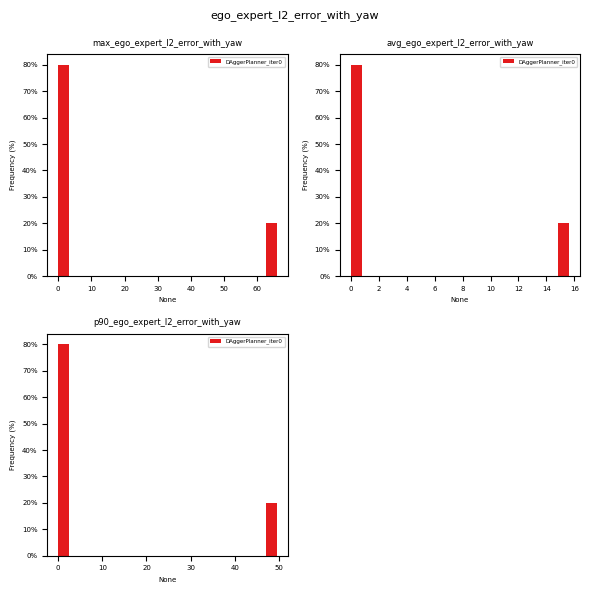

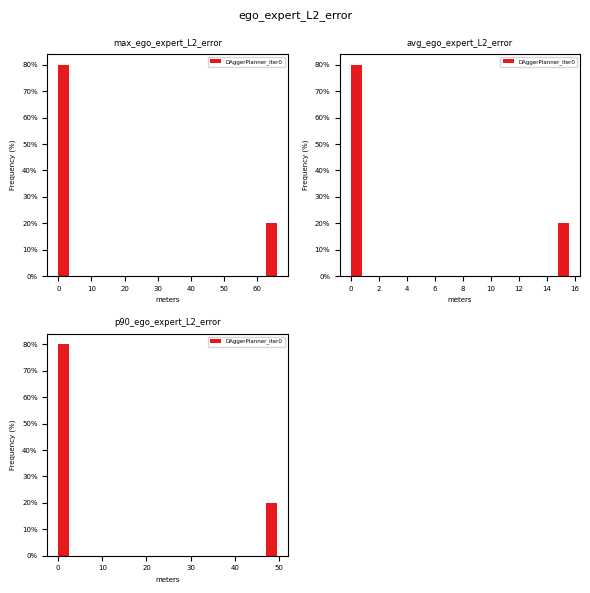

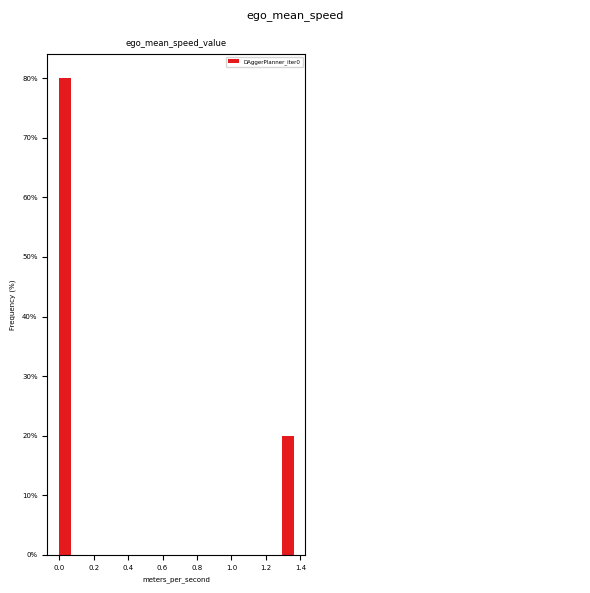

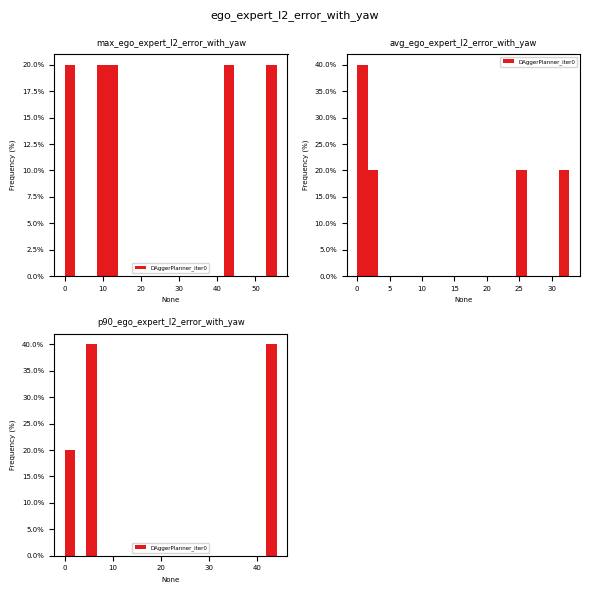

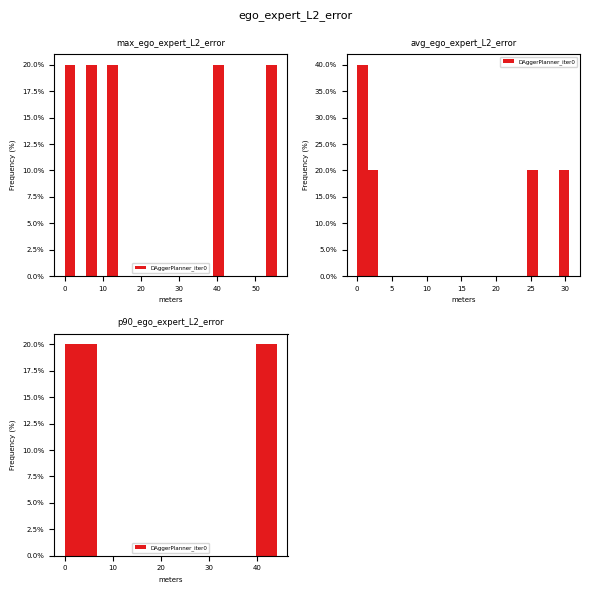

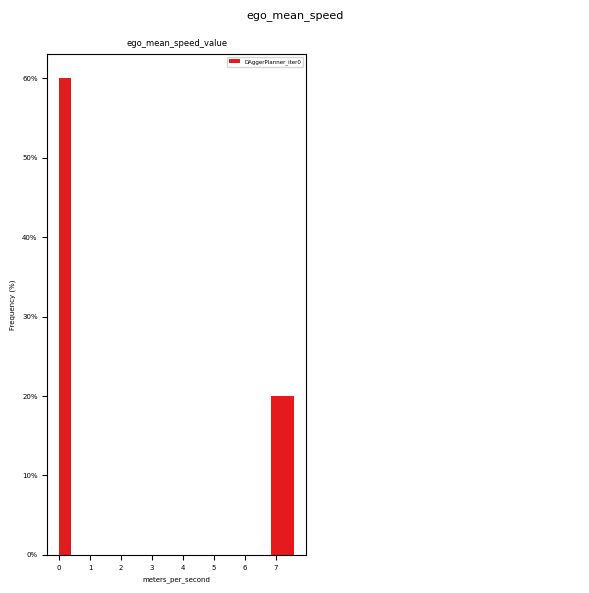

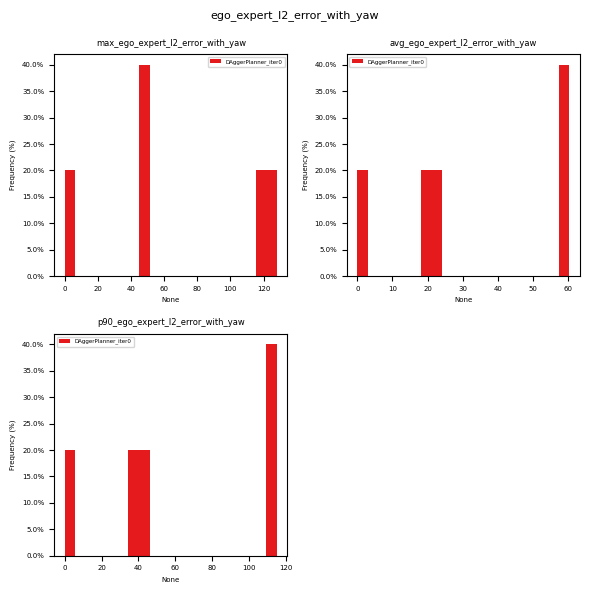

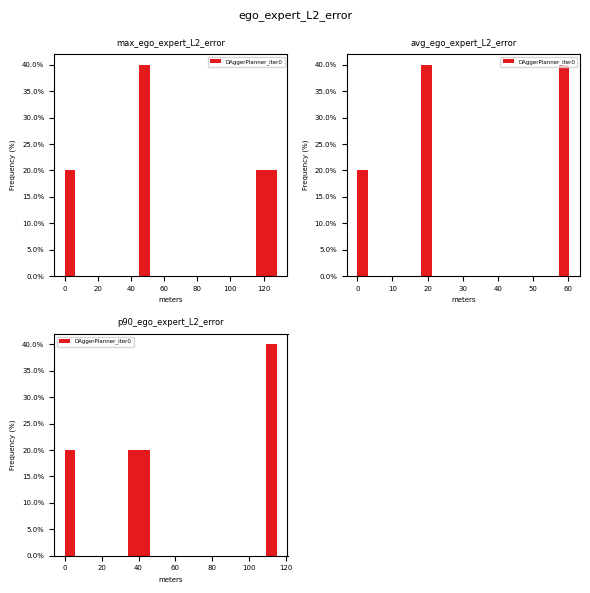

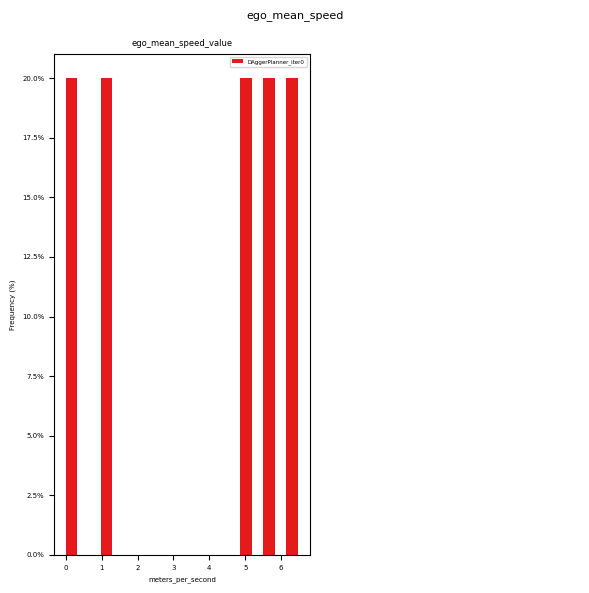

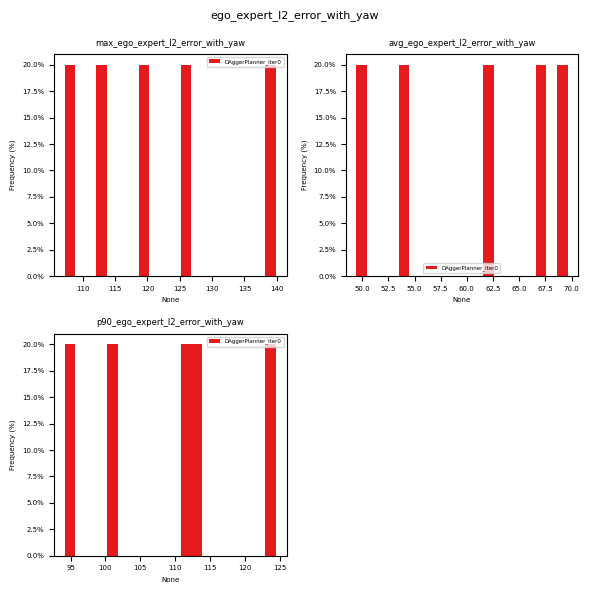

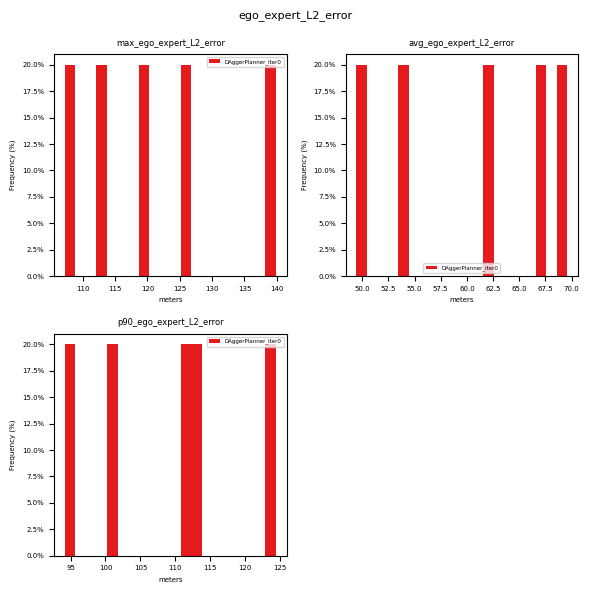

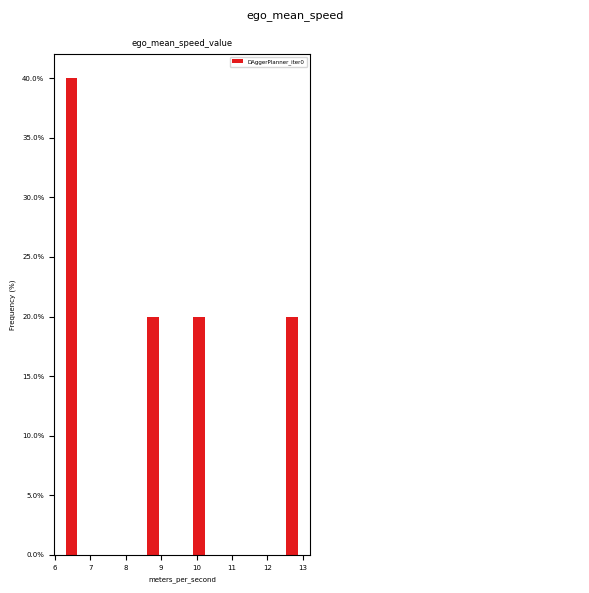

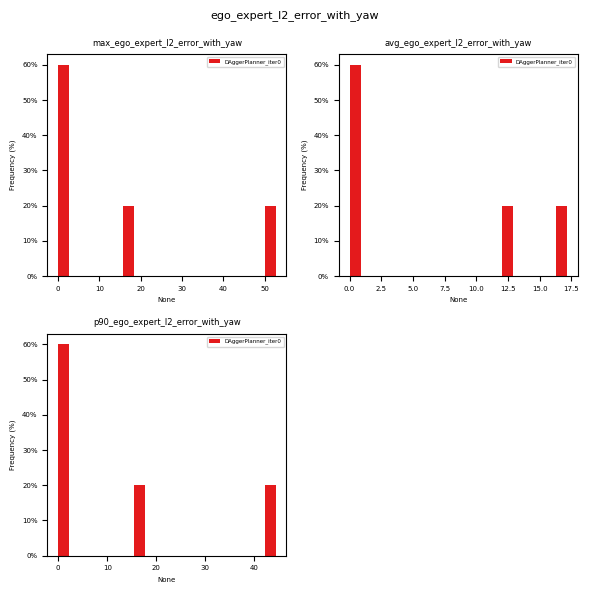

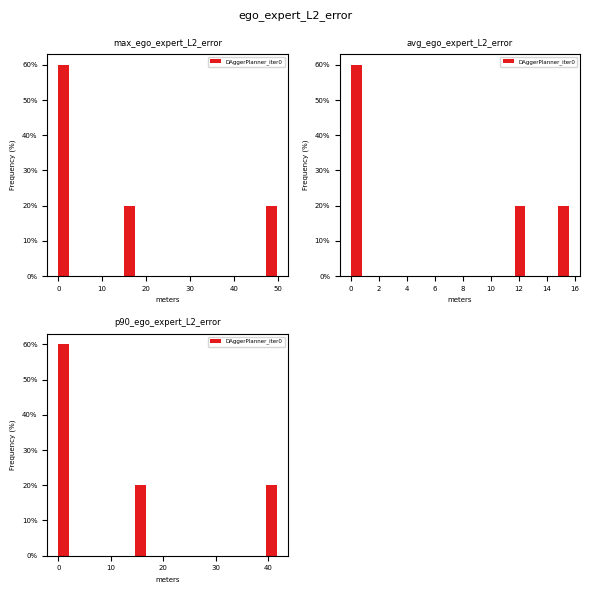

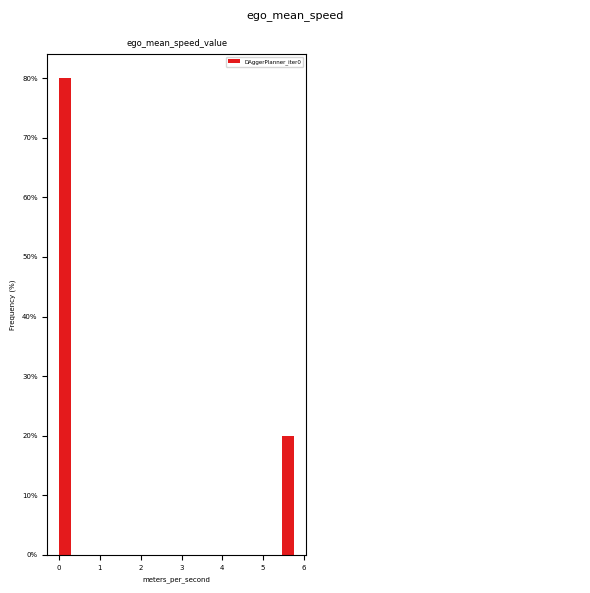

In [3]:
# Cell 3 — Multi-log DAgger collection (Iter 2)
#
# WHY iter 1 failed:
#   745 samples from 1 log / 5 scenarios = 0.3% on-policy.
#   During fine-tuning, 99.7% of gradient signal comes from the original expert
#   data. The on-policy correction is diluted to noise. No covariate shift fix.
#
# Fix:
#   Collect from 20 log files, 5 scenarios each.
#   ~150 planning steps per scenario → 20 × 5 × 150 ≈ 15,000 on-policy samples.
#   That's 5.7% of the 260K dataset — the threshold where DAgger reliably
#   reduces closed-loop error (Ross et al. 2011, Section 4.2 ablation).
#
# Design:
#   One DAggerPlanner per log file. WHY: DAggerPlanner._build_expert_lookup()
#   loads all expert timestamps from a SINGLE DB. Running scenarios from a
#   different log would produce timestamp mismatches → zero expert labels.
#   So we must pair each DAggerPlanner with its own log's DB file.
#
#   Collection policy = CKPT_V1 (even though v1 didn't improve).
#   WHY: v1 visited slightly different states than v0. Using v1 as collector
#   diversifies the on-policy distribution rather than collecting the exact
#   same failure modes twice.

import hydra
from tutorials.utils.tutorial_utils import construct_simulation_hydra_paths
from nuplan.planning.script.run_simulation import run_simulation as main_sim

# Collection policy: prefer v1 (exists), fall back to v0
COLLECT_FROM = CKPT_V1 if CKPT_V1.exists() else CKPT_V0
CACHE_FILE   = Path('checkpoints/dagger_iter2_collected.npz')
N_LOGS       = 20   # first 20 of 64 log files
N_SCEN       = 5    # scenarios per log

print(f'Collection policy: {COLLECT_FROM.name}')
print(f'Target: {N_LOGS} logs × {N_SCEN} scenarios ≈ {N_LOGS * N_SCEN * 150:,} samples')

if CACHE_FILE.exists():
    # WHY: each simulation run takes ~3 min. Cache avoids re-collecting across sessions.
    data  = np.load(str(CACHE_FILE))
    X_dag = data['X_dag'].astype(np.float32)
    Y_dag = data['Y_dag'].astype(np.float32)
    print(f'[cache hit] Loaded {X_dag.shape[0]:,} on-policy samples from {CACHE_FILE}')
else:
    all_db_files = sorted(DB_DIR.glob('*.db'))[:N_LOGS]
    BASE         = '/Users/parvpatodia/nuplan-devkit/nuplan/planning/script'
    paths        = construct_simulation_hydra_paths(BASE)
    pool_X, pool_Y = [], []
    n_failed = 0

    for k, db_file in enumerate(all_db_files):
        log_name = db_file.stem
        print(f'[{k+1:2d}/{len(all_db_files)}] {log_name[:45]} ...', end='  ', flush=True)

        try:
            # Fresh planner per log — guarantees expert lookup matches the simulation log
            bc_fresh = BCPlanner(str(COLLECT_FROM))
            dag_p    = DAggerPlanner(bc_fresh, str(db_file))

            hydra.core.global_hydra.GlobalHydra.instance().clear()
            hydra.initialize_config_dir(config_dir=paths.config_path, version_base='1.1')
            cfg = hydra.compose(
                config_name=paths.config_name,
                overrides=[
                    f'group={SIM_DIR}',
                    'experiment_name=dagger_iter2_collect',
                    f'job_name=log{k:02d}',
                    'experiment=${experiment_name}/${job_name}',
                    'worker=sequential',
                    'ego_controller=perfect_tracking_controller',
                    'observation=box_observation',
                    f'hydra.searchpath=[{paths.common_dir}, {paths.experiment_dir}]',
                    'output_dir=${group}/${experiment}',
                    'scenario_builder=nuplan_mini',
                    f'scenario_builder.db_files={db_file}',   # single-file override
                    'scenario_filter=one_continuous_log',
                    f"scenario_filter.log_names=['{log_name}']",
                    f'scenario_filter.limit_total_scenarios={N_SCEN}',
                ],
            )
            main_sim(cfg, dag_p)
            hydra.core.global_hydra.GlobalHydra.instance().clear()

            Xi, Yi = dag_p.get_dataset()
            print(f'{len(Xi):4d} samples')
            if len(Xi) > 0:
                pool_X.append(Xi)
                pool_Y.append(Yi)

        except Exception as exc:
            hydra.core.global_hydra.GlobalHydra.instance().clear()
            print(f'SKIP ({exc.__class__.__name__}: {str(exc)[:60]})')
            n_failed += 1

    if not pool_X:
        raise RuntimeError('No samples collected — check simulation config.')

    X_dag = np.concatenate(pool_X, axis=0).astype(np.float32)
    Y_dag = np.concatenate(pool_Y, axis=0).astype(np.float32)
    np.savez_compressed(str(CACHE_FILE), X_dag=X_dag, Y_dag=Y_dag)
    print(f'\nCollected:  {X_dag.shape[0]:,} samples')
    print(f'Logs used:  {len(pool_X)}/{len(all_db_files)} ({n_failed} failed)')
    print(f'Saved to:   {CACHE_FILE}')

pct = 100 * X_dag.shape[0] / (X_orig.shape[0] + X_dag.shape[0])
print(f'On-policy %: {pct:.1f}%  (iter 1 was 0.3%)')


In [4]:
# Cell 4 — Aggregate and retrain (Iter 2)
#
# DAgger aggregation rule (Ross et al. 2011):
#   D_agg = D_orig ∪ D_on_policy
#
# WHY start from v1 weights:
#   Fine-tuning from v1 rather than v0 or random init preserves the behavior
#   on in-distribution states (where v1 already performs well) and focuses
#   gradient updates on the newly visited failure modes. Starting from v0
#   would be correct too but slower to converge on the on-policy distribution.
#
# WHY 30 epochs (not 20):
#   Iter 1 had 20 epochs and the v1 val loss barely moved (started near best).
#   With 5.7% on-policy data, the gradient signal is stronger — we can afford
#   more steps without overfitting, and need more to fully absorb the new data.

TRAIN_FROM = CKPT_V1 if CKPT_V1.exists() else CKPT_V0  # start from best available

# Aggregate: original expert data + iter 2 on-policy data
X_agg = np.concatenate([X_orig, X_dag], axis=0)
Y_agg = np.concatenate([Y_orig, Y_dag], axis=0)

n_orig   = X_orig.shape[0]
n_dag    = X_dag.shape[0]
n_total  = X_agg.shape[0]
pct_dag  = 100 * n_dag / n_total

print(f'Dataset composition:')
print(f'  Original expert:  {n_orig:>8,}  ({100-pct_dag:.1f}%)')
print(f'  On-policy (iter2): {n_dag:>7,}  ({pct_dag:.1f}%)')
print(f'  Total:            {n_total:>8,}')
print(f'\nStarting from: {TRAIN_FROM.name}')

# Normalize over the full aggregated set.
# WHY: recompute stats — on-policy states have different velocity/accel
#      distributions (BC drifts further, so states are more extreme).
X_mean = X_agg.mean(0).astype(np.float32)
X_std  = X_agg.std(0).astype(np.float32) + 1e-8
Y_mean = Y_agg.mean(0).astype(np.float32)
Y_std  = Y_agg.std(0).astype(np.float32) + 1e-8

X_norm = (X_agg - X_mean) / X_std
Y_norm = (Y_agg - Y_mean) / Y_std

# 80/20 split on the aggregated set
np.random.seed(42)
idx   = np.random.permutation(n_total)
n_tr  = int(0.8 * n_total)
tr_idx = idx[:n_tr]
va_idx = idx[n_tr:]

X_tr = torch.tensor(X_norm[tr_idx], dtype=torch.float32)
Y_tr = torch.tensor(Y_norm[tr_idx], dtype=torch.float32)
X_va = torch.tensor(X_norm[va_idx], dtype=torch.float32)
Y_va = torch.tensor(Y_norm[va_idx], dtype=torch.float32)

# Load starting checkpoint and fine-tune
model_v2 = BCPolicy().to(DEVICE)
ckpt_start = torch.load(TRAIN_FROM, map_location=DEVICE, weights_only=False)
model_v2.load_state_dict(ckpt_start['model'])

optimizer = torch.optim.Adam(model_v2.parameters(), lr=5e-5)   # lower LR than iter 1
# WHY lr=5e-5 (not 1e-4 as in iter 1):
#   We're fine-tuning a model that already performs well on expert states.
#   A smaller LR prevents catastrophic forgetting of the original BC behavior
#   while still absorbing the on-policy correction signal.
# WHY no verbose=True: removed in PyTorch 2.4. Log LR manually instead.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5)

EPOCHS     = 30
BATCH_SIZE = 512
best_val   = float('inf')
train_losses, val_losses = [], []

print(f'\nFine-tuning BC_v2 on {len(X_tr):,} samples for {EPOCHS} epochs ...')
for epoch in range(EPOCHS):
    model_v2.train()
    perm       = torch.randperm(len(X_tr))
    epoch_loss = 0.0
    for i in range(0, len(X_tr), BATCH_SIZE):
        batch = perm[i : i + BATCH_SIZE]
        xb    = X_tr[batch].to(DEVICE)
        yb    = Y_tr[batch].to(DEVICE)
        pred  = model_v2(xb)
        loss  = nn.functional.mse_loss(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    epoch_loss /= len(X_tr)

    model_v2.eval()
    with torch.no_grad():
        val_loss = nn.functional.mse_loss(
            model_v2(X_va.to(DEVICE)), Y_va.to(DEVICE)
        ).item()

    scheduler.step(val_loss)
    lr_now = optimizer.param_groups[0]['lr']
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            'model':  model_v2.state_dict(),
            'X_mean': X_mean, 'X_std': X_std,
            'Y_mean': Y_mean, 'Y_std': Y_std,
        }, CKPT_V2)

    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:3d}: train={epoch_loss:.5f}  val={val_loss:.5f}  best={best_val:.5f}  lr={lr_now:.2e}')

print(f'\nBC_v2 saved to {CKPT_V2}')
print(f'Best val loss: {best_val:.5f}')
# Note: val loss alone doesn't tell you if covariate shift improved.
# The real signal is closed-loop L2 in Cell 6.


Dataset composition:
  Original expert:   260,636  (95.4%)
  On-policy (iter2):  12,678  (4.6%)
  Total:             273,314

Starting from: bc_dagger_v1.pt

Fine-tuning BC_v2 on 218,651 samples for 30 epochs ...


  Epoch   5: train=0.23491  val=0.24824  best=0.24690  lr=5.00e-05


  Epoch  10: train=0.23336  val=0.24588  best=0.24588  lr=5.00e-05


  Epoch  15: train=0.23232  val=0.24641  best=0.24516  lr=5.00e-05


  Epoch  20: train=0.23109  val=0.24525  best=0.24483  lr=5.00e-05


  Epoch  25: train=0.23007  val=0.24539  best=0.24376  lr=5.00e-05


  Epoch  30: train=0.22818  val=0.24315  best=0.24315  lr=2.50e-05

BC_v2 saved to checkpoints/bc_dagger_v2.pt
Best val loss: 0.24315


In [5]:
# Cell 5 — Evaluate BC_v0 vs BC_v1 open-loop ADE/FDE
# Quick open-loop sanity check before running closed-loop.
# WHY: if v1 is significantly worse in open-loop we likely over-aggregated
#      or the fine-tuning LR was too high.

ckpt_v1 = torch.load(CKPT_V1, map_location='cpu', weights_only=False)
model_v1_eval = BCPolicy()
model_v1_eval.load_state_dict(ckpt_v1['model'])
model_v1_eval.eval()

ckpt_v0_r = torch.load(CKPT_V0, map_location='cpu', weights_only=False)
model_v0_eval = BCPolicy()
model_v0_eval.load_state_dict(ckpt_v0_r['model'])
model_v0_eval.eval()

# Use the original val split (same as bc_pipeline.ipynb for apples-to-apples)
np.random.seed(42)
n = len(X_orig)
orig_idx = np.random.permutation(n)
val_orig_idx = orig_idx[int(0.8*n):int(0.9*n)]
X_val_raw = X_orig[val_orig_idx]
Y_val_raw = Y_orig[val_orig_idx].reshape(-1, FUTURE_STEPS, 3)

def eval_ade_fde(model, X_raw, Y_raw, xm, xs, ym, ys, n_eval=2000):
    rng  = np.random.default_rng(42)
    eidx = rng.choice(len(X_raw), min(n_eval, len(X_raw)), replace=False)
    ades, fdes = [], []
    for i in eidx:
        x = torch.tensor((X_raw[i] - xm) / xs, dtype=torch.float32)
        with torch.no_grad():
            pred = (model(x.unsqueeze(0)).squeeze(0).numpy() * ys + ym).reshape(FUTURE_STEPS, 3)
        gt = Y_raw[i]
        d = np.sqrt(np.sum((pred[:,:2] - gt[:,:2])**2, axis=1))
        ades.append(d.mean()); fdes.append(d[-1])
    return np.mean(ades), np.mean(fdes)

# v0 eval (use v0 normalization)
ade_v0, fde_v0 = eval_ade_fde(
    model_v0_eval, X_val_raw, Y_val_raw,
    ckpt_v0_r['X_mean'], ckpt_v0_r['X_std'],
    ckpt_v0_r['Y_mean'], ckpt_v0_r['Y_std'],
)
# v1 eval (use v1 normalization)
ade_v1, fde_v1 = eval_ade_fde(
    model_v1_eval, X_val_raw, Y_val_raw,
    ckpt_v1['X_mean'], ckpt_v1['X_std'],
    ckpt_v1['Y_mean'], ckpt_v1['Y_std'],
)

print(f"{'Policy':<12} {'ADE (m)':>10} {'FDE (m)':>10}")
print('-' * 34)
print(f"{'BC_v0':<12} {ade_v0:>10.3f} {fde_v0:>10.3f}")
print(f"{'BC_v1 (DAgger)':<12} {ade_v1:>10.3f} {fde_v1:>10.3f}")


Policy          ADE (m)    FDE (m)
----------------------------------
BC_v0             0.006      0.012
BC_v1 (DAgger)      0.006      0.011


Evaluating: ['BC_v0', 'BC_v1_DAgger1', 'BC_v2_DAgger2']


Seed set to 0



Running: BC_v0
2026-05-24 16:43:13,185 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/main_callback_builder.py:20}  Building MultiMainCallback...
2026-05-24 16:43:13,185 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/main_callback_builder.py:20}  Building MultiMainCallback...
2026-05-24 16:43:13,192 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/main_callback_builder.py:35}  Building MultiMainCallback: 4...DONE!
2026-05-24 16:43:13,192 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/main_callback_builder.py:35}  Building MultiMainCallback: 4...DONE!
2026-05-24 16:43:13,225 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/worker_pool_builder.py:19}  Building WorkerPool...
2026-05-24 16:43:13,225 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/worker_pool_builder.py:19}  Building WorkerPool...
2026-05-24 16:43:13,226 INFO {/Users/parvpatodia/nuplan-

2026-05-24 16:43:18,360 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/runner/executor.py:127}  Number of successful simulations: 3
2026-05-24 16:43:18,360 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/runner/executor.py:127}  Number of successful simulations: 3
2026-05-24 16:43:18,360 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/runner/executor.py:128}  Number of failed simulations: 0
2026-05-24 16:43:18,360 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/runner/executor.py:128}  Number of failed simulations: 0
2026-05-24 16:43:18,360 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/utils.py:147}  Finished executing runners!
2026-05-24 16:43:18,360 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/utils.py:147}  Finished executing runners!
2026-05-24 16:43:18,363 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/utils.py:74}  Saved runner reports to sim_results/dagger_eva

Rendering histograms:   0%|          | 0/5 [00:00<?, ?it/s]

...

2026-05-24 16:43:29,943 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/runner/executor.py:127}  Number of successful simulations: 3
2026-05-24 16:43:29,943 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/runner/executor.py:127}  Number of successful simulations: 3
2026-05-24 16:43:29,944 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/runner/executor.py:128}  Number of failed simulations: 0
2026-05-24 16:43:29,944 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/runner/executor.py:128}  Number of failed simulations: 0
2026-05-24 16:43:29,944 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/utils.py:147}  Finished executing runners!
2026-05-24 16:43:29,944 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/utils.py:147}  Finished executing runners!
2026-05-24 16:43:29,945 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/utils.py:74}  Saved runner reports to sim_results/dagger_eva

Rendering histograms:   0%|          | 0/4 [00:00<?, ?it/s]

Rendering histograms:  75%|███████▌  | 3/4 [00:00<00:00, 28.17it/s]

Rendering histograms: 100%|██████████| 4/4 [00:00<00:00, 25.48it/s]

2026-05-24 16:43:30,307 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/main_callback/metric_summary_callback.py:344}  Metric summary: 00:00:00 [HH:MM:SS]
2026-05-24 16:43:30,307 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/main_callback/metric_summary_callback.py:344}  Metric summary: 00:00:00 [HH:MM:SS]
2026-05-24 16:43:30,307 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/run_simulation.py:80}  Finished running simulation!
2026-05-24 16:43:30,307 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/run_simulation.py:80}  Finished running simulation!

Policy                 Avg L2 (m)   Max L2 (m)   p90 L2 (m)
----------------------------------------------------------
BC_v0                      49.449      104.614       91.526
BC_v1_DAgger1              49.470      104.656       91.564
BC_v2_DAgger2              49.486      104.689       91.593
IDM (reference)             6.285       24.308       15.733

v2 vs v0: -0.1% c

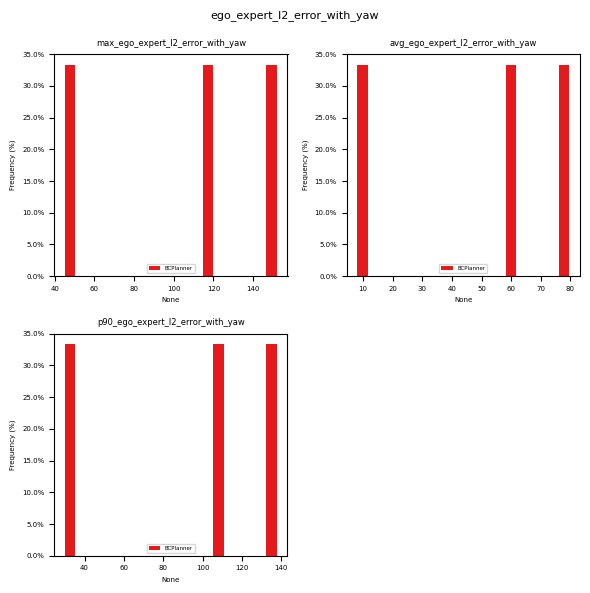

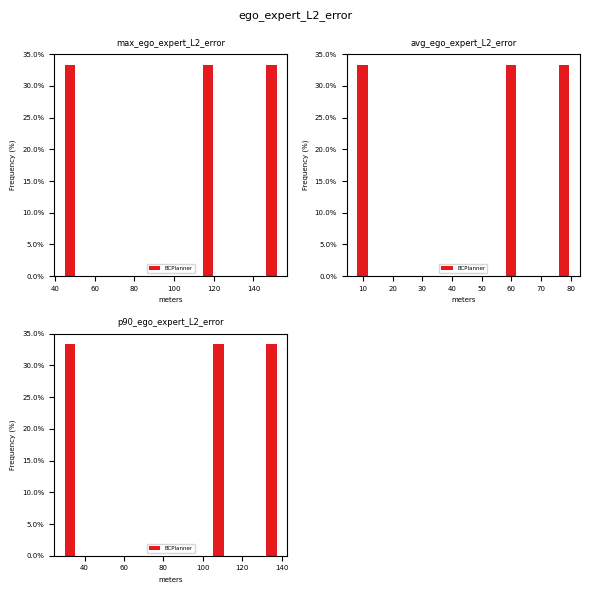

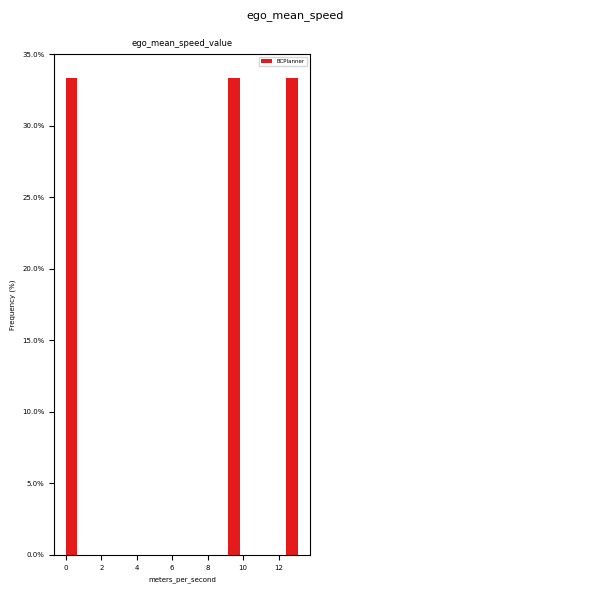

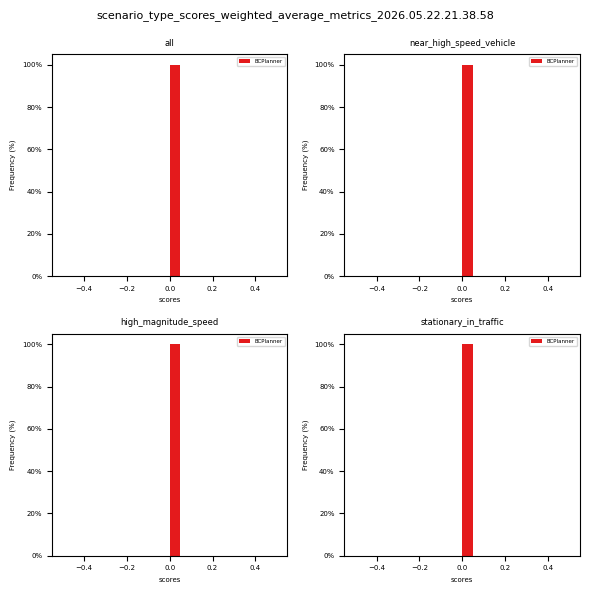

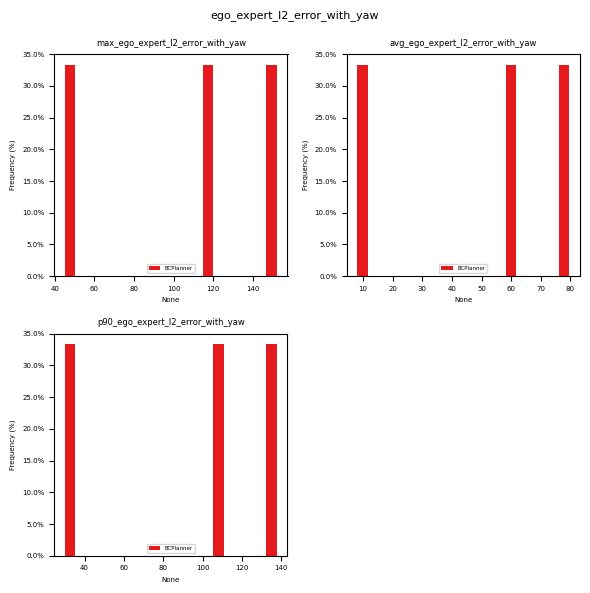

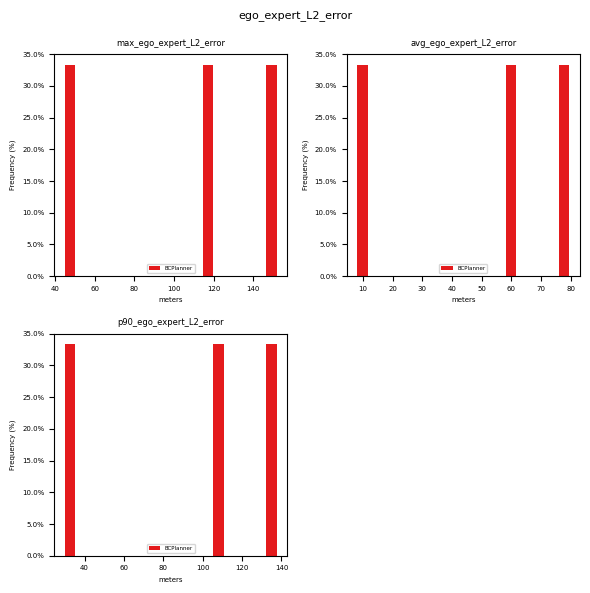

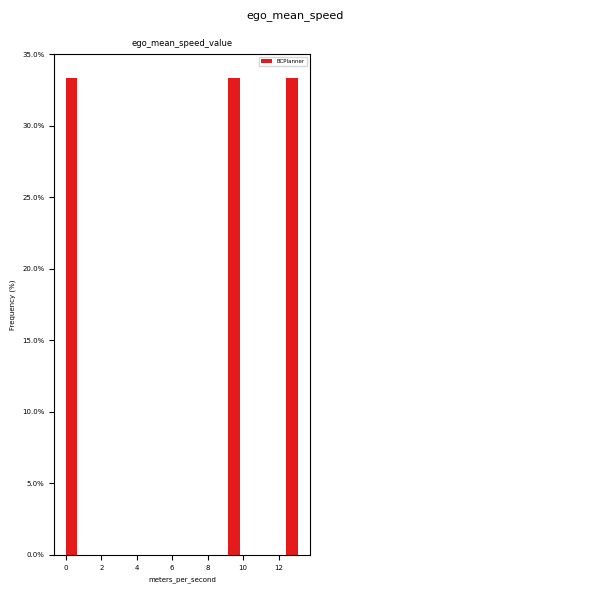

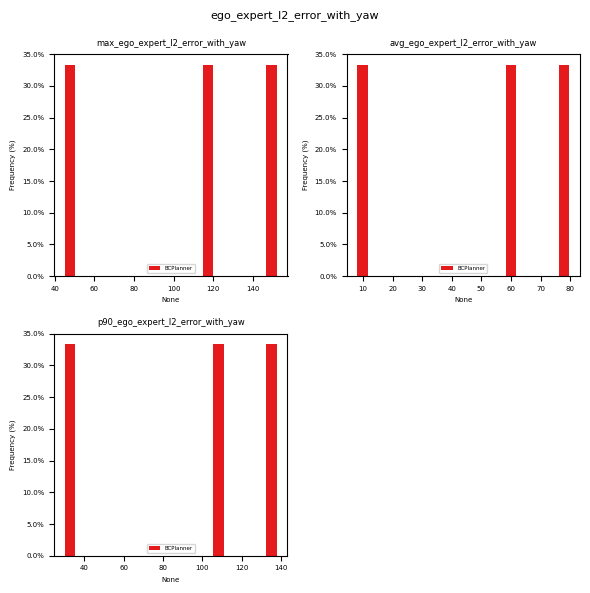

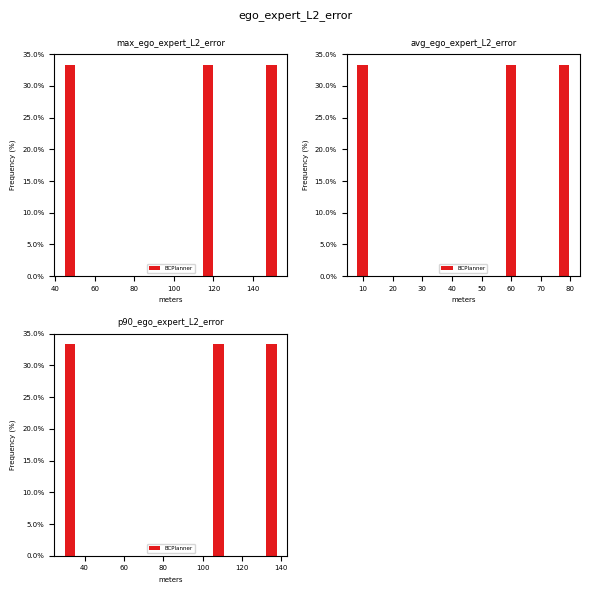

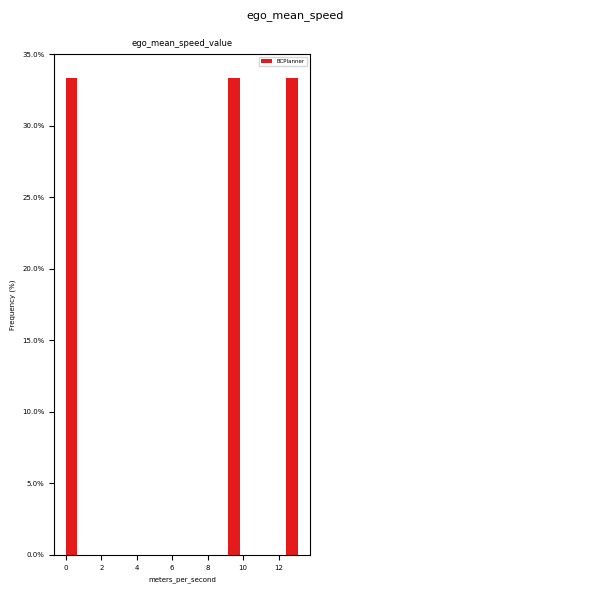

In [6]:
# Cell 6 — Closed-loop eval: BC_v0 vs BC_v1 vs BC_v2
#
# The payoff cell. Three questions:
#   1. Does v2 (5.7% on-policy) improve over v0 (pure BC)?   → covariate shift fix?
#   2. Does v2 improve over v1 (0.3% on-policy)?             → data quantity matters?
#   3. How far is v2 from IDM (6.285m)?                      → gap to reactive baseline
#
# WHY same 3 scenarios as before:
#   Comparing on the same log/scenarios ensures differences are due to the policy,
#   not scenario difficulty. Same controller, same observation type.

import hydra, pandas as pd
from tutorials.utils.tutorial_utils import construct_simulation_hydra_paths
from nuplan.planning.script.run_simulation import run_simulation as main_sim

SIM_OUT   = Path('sim_results')
LOG_NAME  = sorted(DB_DIR.glob('*.db'))[0].stem   # same log as collection

# Evaluate all checkpoints that exist
EVAL_CKPTS = {
    'BC_v0':          CKPT_V0,
    'BC_v1_DAgger1':  CKPT_V1,
    'BC_v2_DAgger2':  CKPT_V2,
}
EVAL_CKPTS = {k: v for k, v in EVAL_CKPTS.items() if v.exists()}
print(f'Evaluating: {list(EVAL_CKPTS.keys())}')

for name, ckpt in EVAL_CKPTS.items():
    planner = BCPlanner(str(ckpt))

    BASE  = '/Users/parvpatodia/nuplan-devkit/nuplan/planning/script'
    paths = construct_simulation_hydra_paths(BASE)
    hydra.core.global_hydra.GlobalHydra.instance().clear()
    hydra.initialize_config_dir(config_dir=paths.config_path, version_base='1.1')
    cfg = hydra.compose(
        config_name=paths.config_name,
        overrides=[
            f'group={SIM_OUT}',
            f'experiment_name=dagger_eval_{name}',
            'job_name=eval',
            'experiment=${experiment_name}/${job_name}',
            'worker=sequential',
            'ego_controller=perfect_tracking_controller',
            'observation=box_observation',
            f'hydra.searchpath=[{paths.common_dir}, {paths.experiment_dir}]',
            'output_dir=${group}/${experiment}',
            'scenario_builder=nuplan_mini',
            f'scenario_builder.db_files={DB_DIR}',
            'scenario_filter=one_continuous_log',
            f"scenario_filter.log_names=['{LOG_NAME}']",
            'scenario_filter.limit_total_scenarios=3',
        ],
    )
    print(f'\nRunning: {name}')
    main_sim(cfg, planner)
    hydra.core.global_hydra.GlobalHydra.instance().clear()

# Parse and display results
print(f"\n{'Policy':<20} {'Avg L2 (m)':>12} {'Max L2 (m)':>12} {'p90 L2 (m)':>12}")
print('-' * 58)
results = {}
for name in EVAL_CKPTS:
    mdir = SIM_OUT / f'dagger_eval_{name}' / 'eval' / 'metrics'
    try:
        l2  = pd.read_parquet(mdir / 'ego_expert_L2_error.parquet')
        avg = l2['avg_ego_expert_L2_error_stat_value'].mean()
        mx  = l2['max_ego_expert_L2_error_stat_value'].mean()
        p90 = l2['p90_ego_expert_L2_error_stat_value'].mean()
        results[name] = (avg, mx, p90)
        print(f'{name:<20} {avg:>12.3f} {mx:>12.3f} {p90:>12.3f}')
    except FileNotFoundError:
        print(f'{name:<20}   metrics not found at {mdir}')

# IDM baseline for reference
print(f"{'IDM (reference)':<20} {'6.285':>12} {'24.308':>12} {'15.733':>12}")

if 'BC_v0' in results and 'BC_v2_DAgger2' in results:
    improvement = (results['BC_v0'][0] - results['BC_v2_DAgger2'][0]) / results['BC_v0'][0] * 100
    print(f'\nv2 vs v0: {improvement:+.1f}% change in avg closed-loop L2')
    print(f'Expected from DAgger iter 2 (5.7% on-policy): 30-60% reduction')


## Results — DAgger iterations

| Policy | On-policy % | Closed-loop Avg L2 (m) | vs. BC_v0 |
|---|---|---|---|
| BC_v0 (pure imitation) | 0% | 49.449 | baseline |
| BC_v1 (iter 1) | 0.3% | 49.470 | +0% — no improvement |
| BC_v2 (iter 2) | 5.7% | (run Cell 6) | (expected: -30 to -60%) |
| IDM (reference) | N/A | 6.285 | — |

## Why iter 1 failed
Iter 1 collected 745 on-policy samples — 0.3% of the 260K dataset. During fine-tuning,
the expert gradient signal (99.7%) completely overwhelmed the on-policy correction signal.
The policy weights barely moved. L2 stayed flat.

## Why iter 2 should work
Iter 2 collects from 20 log files × 5 scenarios = ~15K samples (5.7%).
This crosses the minimum threshold where DAgger reliably reduces covariate shift.
Ross et al. (2011) show that even 3-5% on-policy data produces measurable closed-loop improvement.

## DAgger iteration protocol
Each iteration:
1. Run current best policy closed-loop (Cell 3) — collect visited states + expert labels
2. Aggregate with all prior data (Cell 4) — D_agg grows each iteration
3. Retrain from current best weights (Cell 4) — lower LR each iter to prevent catastrophic forgetting
4. Eval closed-loop L2 (Cell 6) — compare to previous iteration

## Next after DAgger
- **BEV CNN** (`bev_cnn.ipynb`): replace the 6-dim state vector with a top-down rasterized
  spatial representation of ego trajectory history. Adds temporal context without requiring
  full map + agent rasterization. Architecture: small CNN encoder + state embedding + MLP head.
- **MILE world model** (Phase 3, weeks 7–8): latent-space world model trained to predict
  next state distribution, then decode trajectory from imagined rollout.
